# Delhi House Price Prediction

### Project Overview:
The objective of this project is to build a predictive model to estimate the price of houses in Delhi using various property-related features. The model will help buyers and sellers understand fair market prices based on house characteristics such as area, locality, and number of rooms.

### Dataset Information:
The dataset contains 1259 rows and 11 columns collected from Kaggle. Each row represents a unique property listing in Delhi.

### Independent and Dependent Variables (Features)
These are the independent variables that help predict the price:
1. Area: Area of the house in square feet, directly affects price (larger area → higher price)
2. BHK: Number of bedrooms, more bedrooms → higher price
3. Bathroom: Number of bathrooms, more bathrooms → higher price
4. Furnishing: Furnishing status, (e.g., Fully Furnished, Semi-Furnished, Unfurnished)
5. Locality: Locality of the house, different localities have different market values
6. Parking: Number of parking available, houses with parking generally have higher prices
7. Status: property's status as in 'ready to move' or still under construction, (Ready to move / Under construction)
8. Transaction: Its a new property or being re-sold, (New property / Resale)
9. Type: Type of the property, Apartment / Builder Floor / House / Villa)
10. Per_Sqft: Price per square feet, derived feature, gives cost efficiency of the property

Dependent Variables of the dataset:
1. Price: Price of the house in INR

### Data Preprocessing Steps
* Handling missing values
* Converting categorical variables to numerical (e.g., using One-Hot Encoding or Label Encoding)
* Feature scaling for numerical columns
* Outlier detection and treatment
* Splitting the data into training and testing sets

### Exploratory Data Analysis (EDA)
Include Plots such as
* Price vs Area
* Price vs BHK
* Price distribution across localities
* Average price by furnishing status or property type
These help visualize relationships and understand which features affect price the most.

### Model Building
* Linear Regression
* Decision Tree Regressor
* Random Forest Regressor
* Gradient Boosting/ XGBOOST

Can compare model performance using:
* R-Squared
* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)

### Import Libraries

In [5]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [7]:
# Load The Dataset
df = pd.read_csv('MagicBricks.csv')

In [8]:
# Show the first five rows of the dataset
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [9]:
# Show the last five rows of the dataset
df.tail()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0
1258,11050.0,3,3.0,Unfurnished,Chittaranjan Park,1.0,18500000,Ready_to_move,New_Property,Builder_Floor,12916.0


### Data Preprocessing

In [11]:
# Display the dimensions (shape) of the dataset
df.shape

(1259, 11)

In [12]:
# Display the dataset information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Locality     1259 non-null   object 
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   object 
 8   Transaction  1259 non-null   object 
 9   Type         1254 non-null   object 
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 108.3+ KB


In [13]:
# Statistical Summary for Numerical Variables
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [14]:
# Statistical Summary for Categorical Variables
df.describe(include = 'object')

,Furnishing,Locality,Status,Transaction,Type
count,1254,1259,1259,1259,1254
unique,3,365,2,2,2
top,Semi-Furnished,Lajpat Nagar 3,Ready_to_move,Resale,Builder_Floor
freq,708,34,1184,781,661


### Identifying Numerical and Categorical Variables

In [16]:
# Identifying Numerical Variables in the dataset
numerical_vars = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
num_numerical_vars = len(numerical_vars)
print(f"Count of Numerical Variables: , {num_numerical_vars}")
print(f"Numerical Variables Features are: , {numerical_vars}")

Count of Numerical Variables: , 6
Numerical Variables Features are: , ['Area', 'BHK', 'Bathroom', 'Parking', 'Price', 'Per_Sqft']


In [17]:
# Identifying Categorical Variables in the dataset
categorical_vars = [col for col in df.columns if df[col].dtype in ['object']]
num_categorical_vars = len(categorical_vars)
print(f"Count of Categorical Variables: , {num_categorical_vars}")
print(f"Categorical Variables Features are: , {categorical_vars}")

Count of Categorical Variables: , 5
Categorical Variables Features are: , ['Furnishing', 'Locality', 'Status', 'Transaction', 'Type']


### Checking Duplicates

In [19]:
# Shape of the dataset before dropping duplicates
print("Shape of the dataset before dropping duplicates:", df.shape)

# Checking Duplicates before dropping
print("Duplicates records in the dataset before dropping:", df.duplicated().sum())

Shape of the dataset before dropping duplicates: (1259, 11)
Duplicates records in the dataset before dropping: 83


In [20]:
# Dropping Duplicates Records
df = df.drop_duplicates()

# Checking Duplicates after dropping
print("Duplicates records in the dataset after dropping:", df.duplicated().sum())

# Shape of the dataset after dropping duplicates
print("Shape of the dataset after dropping duplicates:", df.shape)

Duplicates records in the dataset after dropping: 0
Shape of the dataset after dropping duplicates: (1176, 11)


### Handling Missing Values

Missing values can arise due to incomplete data collection or entry errors. Identifying and treating them is essential to maintain the quality and accuracy of the predictive model.

In [22]:
# Checking Missing Values in the dataset
df.isnull().sum()

Area             0
BHK              0
Bathroom         1
Furnishing       5
Locality         0
Parking         31
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       227
dtype: int64

**Interpretation**
* The dataset contains 270 missing values in total, spread across several columns.
* The most significant missing values are in:
   * Per_Sqft → 227 missing values
   * Parking → 31 missing values
   * Furnishing and Type → 5 each
   * Bathroom → 1 missing value
* Columns such as Area, BHK, Locality, Price, Status, and Transaction are complete.

In [24]:
# Fill missing values for numerical columns with median
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Parking'] = df['Parking'].fillna(df['Parking'].median())

In [25]:
# Fill missing value for Per_Sqft
df['Per_Sqft'] = df['Per_Sqft'].fillna(df['Price'] / df['Area'])

In [26]:
# Fill missing values for categorical columns with mode
df['Furnishing'] = df['Furnishing'].fillna(df['Furnishing'].mode()[0])
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

In [27]:
# Verify missing values are handled
df.isnull().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Per_Sqft       0
dtype: int64

In [28]:
# Checking Data Types of each Column
df.dtypes

Area           float64
BHK              int64
Bathroom       float64
Furnishing      object
Locality        object
Parking        float64
Price            int64
Status          object
Transaction     object
Type            object
Per_Sqft       float64
dtype: object

Number of Bathrooms and Parking can't be in Float, so converting them to integer. 

In [30]:
# Converting Columns 'Bathroom' and 'Parking' from Float to Int.
# Type casting
df[['Bathroom', 'Parking']] = df[['Bathroom', 'Parking']].astype('int64')

# Verify conversions
df[['Bathroom', 'Parking']].dtypes

Bathroom    int64
Parking     int64
dtype: object

### Get the Unique Value of each Column

To understand the diversity and variability in the dataset, we calculated the number of unique values for each column

In [32]:
# Show unique value count of each variable
df.nunique()

Area           315
BHK              8
Bathroom         7
Furnishing       3
Locality       365
Parking          9
Price          284
Status           2
Transaction      2
Type             2
Per_Sqft       433
dtype: int64

**Interpretation**
* Continuous Numerical Features:
  * Area (315 unique values), Price (284), and Per_Sqft (433) indicate continuous variability.
* Discrete Numerical Features:
  * BHK (8), Bathroom (7), and Parking (9) represent discrete counts.
* Categorical Features:
  * Furnishing (3), Status (2), Transaction (2), Type (2) show limited categories.
 
The dataset contains a mix of continuous, discrete, and categorical variables. Features like Area, Price, and Per_Sqft show high variability, while Furnishing, Status, Transaction, and Type have few distinct categories. The

### Adding new area column in Sq Yards for better understanding of area

In [35]:
# Adding new area column in Sq Yards for better understanding of area
df['Area_Yards'] = df['Area']/9

A new column Area_Yards was created by converting the property area from square feet to square yards using the formula Area_Yards = Area / 9. This conversion improves interpretability since real estate in Delhi is commonly measured in square yards.

In [37]:
# Dispaly the dataset
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,Area_Yards
0,800.0,3,2,Semi-Furnished,Rohini Sector 25,1,6500000,Ready_to_move,New_Property,Builder_Floor,8125.0,88.888889
1,750.0,2,2,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1,5000000,Ready_to_move,New_Property,Apartment,6667.0,83.333333
2,950.0,2,2,Furnished,"Citizen Apartment, Rohini Sector 13",1,15500000,Ready_to_move,Resale,Apartment,6667.0,105.555556
3,600.0,2,2,Semi-Furnished,Rohini Sector 24,1,4200000,Ready_to_move,Resale,Builder_Floor,6667.0,66.666667
4,650.0,2,2,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0,72.222222


In [38]:
# Using Z - score to remove outliers
from scipy import stats

# Z- score
z = np.abs(stats.zscore(df[df.dtypes[df.dtypes != 'object'].index]))

# Removing Outliers
df = df[(z < 3).all(axis = 1)]

### Descriptive Statistics

In [40]:
# Checking descriptive statistics of the data
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft,Area_Yards
count,1110.000000,1110.000000,1110.000000,1110.00000,1.110000e+03,1110.000000,1110.000000
mean,1291.840083,2.731532,2.481982,1.41982,1.846439e+07,12562.496608,143.537787
std,756.141951,0.866154,0.965192,0.73085,1.766207e+07,8486.475827,84.015772
min,28.000000,1.000000,1.000000,1.00000,1.000000e+06,1250.000000,3.111111
25%,800.000000,2.000000,2.000000,1.00000,5.600000e+06,6526.000000,88.888889
50%,1150.000000,3.000000,2.000000,1.00000,1.350000e+07,10700.000000,127.777778
75%,1600.000000,3.000000,3.000000,2.00000,2.497500e+07,16176.000000,177.777778
max,5220.000000,5.000000,5.000000,10.00000,9.300000e+07,72000.000000,580.000000


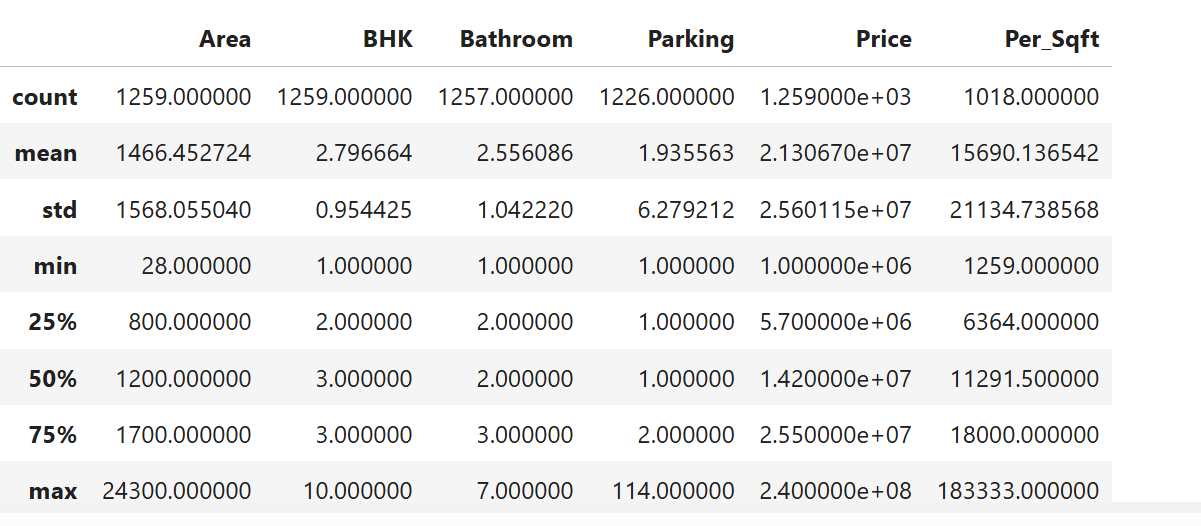

In [42]:
df.head(10)

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,Area_Yards
0,800.0,3,2,Semi-Furnished,Rohini Sector 25,1,6500000,Ready_to_move,New_Property,Builder_Floor,8125.0,88.888889
1,750.0,2,2,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1,5000000,Ready_to_move,New_Property,Apartment,6667.0,83.333333
2,950.0,2,2,Furnished,"Citizen Apartment, Rohini Sector 13",1,15500000,Ready_to_move,Resale,Apartment,6667.0,105.555556
3,600.0,2,2,Semi-Furnished,Rohini Sector 24,1,4200000,Ready_to_move,Resale,Builder_Floor,6667.0,66.666667
4,650.0,2,2,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0,72.222222
5,1300.0,4,3,Semi-Furnished,Rohini Sector 24,1,15500000,Ready_to_move,New_Property,Builder_Floor,6667.0,144.444444
6,1350.0,4,3,Semi-Furnished,Rohini Sector 24,1,10000000,Ready_to_move,Resale,Builder_Floor,6667.0,150.000000
7,650.0,2,2,Semi-Furnished,"Delhi Homes, Rohini Sector 24",1,4000000,Ready_to_move,New_Property,Apartment,6154.0,72.222222
8,985.0,3,3,Unfurnished,Rohini Sector 21,1,6800000,Almost_ready,New_Property,Builder_Floor,6154.0,109.444444
9,1300.0,4,4,Semi-Furnished,Rohini Sector 22,1,15000000,Ready_to_move,New_Property,Builder_Floor,6154.0,144.444444


## Exploratory Data Analysis

In the exploratory data analysis, I will be looking at the data and try to undersatnd the data. I will begin by looking at the distribution of data across the dataset, followed by visualizing the data to understand the relationship between the features and the target variable.

### Area of Houses

In [45]:
# Value Count for each Value of 'Area'
print(df['Area'].value_counts())

Area
900.0     65
1500.0    46
1800.0    42
1000.0    37
1600.0    35
          ..
2025.0     1
2035.0     1
150.0      1
3250.0     1
4118.0     1
Name: count, Length: 283, dtype: int64


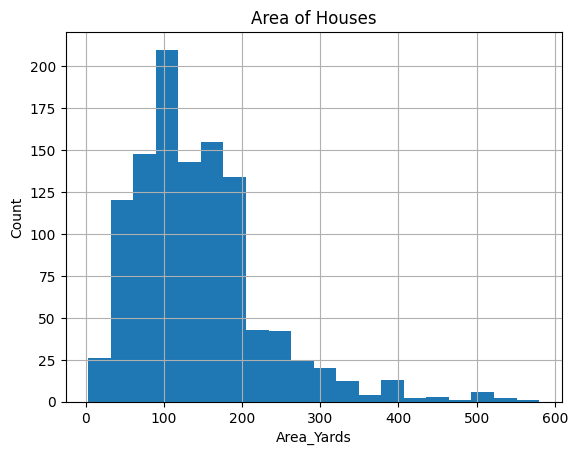

In [46]:
# Plot a 'Histogram' for the 'Area of Houses'
df['Area_Yards'].hist(bins = 20)
plt.title('Area of Houses')
plt.xlabel('Area_Yards')
plt.ylabel('Count')
plt.show()

Looking at the distribution of Area if houses in Delhi most of the houses have area between 80 - 200 sq. yards. This means that most of the houses in Delhi are small houses and there are few house having area near 300 sq yards. Whereas thery are very few houses having area more than 400 sq yards. This representation helps us to know about availability of space in Delhi.

### BHK

In [49]:
# Get Value Count for each value 'BHK'
print(df['BHK'].value_counts())

BHK
3    489
2    338
4    186
1     85
5     12
Name: count, dtype: int64


Text(0.5, 1.0, 'Number of Bedrooms (BHK)')

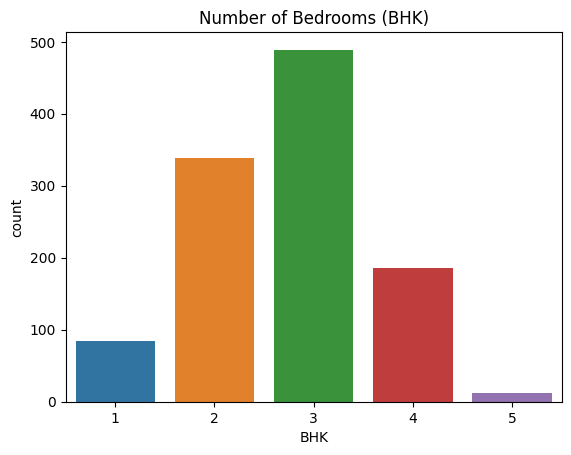

In [50]:
sns.countplot(x = 'BHK', data = df).set_title('Number of Bedrooms (BHK)')

BHK - Bedroom Hall Kitchen. From this graph we can get a little idea about the design of most of houses in Delhi. Most of houses are 3 BHK followed by 2, 4, 1 and 5 BHK houses. Majority of the houses have area between 80-200 sq. yards. Houses with area near 200 yards can have maximum 3 bedrooms, for houses with area near 100 can have 2 bedrooms and 1 bedroom for houses with area less than 80 sq yards. Moreover who is having area more than 300 are less in number so the count of 4BHK and 5BHK. Thus, there is a relation between the BHK and area of house, with this relation we can get a idea about the structure of houses.

### Bathroom Count

In [53]:
# Get Value Count'Bathroom'
print(df['Bathroom'].value_counts()) 

Bathroom
2    506
3    316
1    134
4    109
5     45
Name: count, dtype: int64


Text(0.5, 1.0, 'Number of Bathrooms')

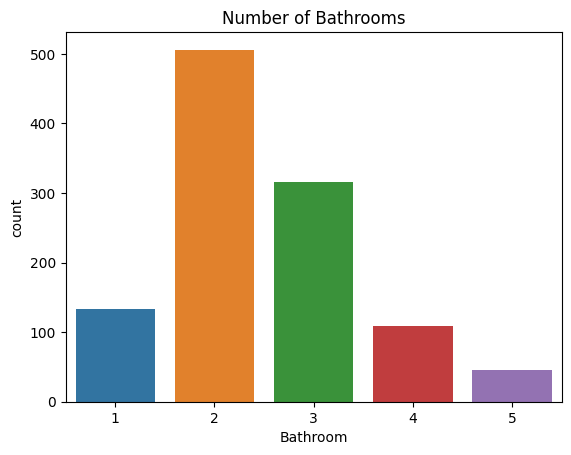

In [54]:
sns.countplot(x = 'Bathroom', data = df).set_title('Number of Bathrooms')

Majority of the houses have 2 bathrooms which, is quite obvious. However there some houses having 3 or more than 3 bathrooms, which is means these houses are quite big and spacious to have 3 or more bathrooms. Smaller houses usually have 1 bathroom.

### Furnishing

In [57]:
# Get Value Count'Furnishing'
print(df['Furnishing'].value_counts())

Furnishing
Semi-Furnished    638
Unfurnished       308
Furnished         164
Name: count, dtype: int64


Text(0.5, 1.0, 'Types of Furnishing')

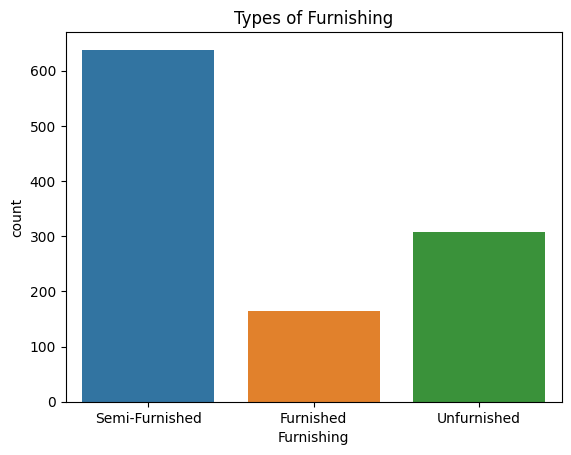

In [58]:
sns.countplot(x = 'Furnishing', data = df).set_title('Types of Furnishing')

Delhi is very close captial of India, New Delhi and many people migrate from various regions of the country mostly for employment reasons to this region. As these people look for accomodations, the furnishing of the houses play a major role. People who are migrationg from huge distances cannot afford to move their furniture and other household items. Hence, they look for fully furnished houses. Similarly the people from neighbouring states might prefer semi-furnished houses, whereas Delhi locals who are moving to some other reason might prefer unfurnished houses. Hence, the furnishing of the house plays a major role in the price of the house. Hence, we have included this feature in our dataset.

### Locality

### Grouping the House Locality

In [62]:
# Show the value count for 'Locality'
print(df['Locality'].value_counts())

# Unique Values for 'Locality'
df['Locality'].unique()

Locality
Lajpat Nagar 2                            30
Kailash Colony, Greater Kailash           29
Lajpat Nagar 3                            28
J R Designers Floors, Rohini Sector 24    28
Yamuna Vihar, Shahdara                    25
                                          ..
Anupam Enclave, Saket                      1
Metrotech Builder Floors, Saket            1
Saket Court Residential Complex, Saket     1
Project Paryavaran Complex, Saket          1
Chittaranjan Park Block A                  1
Name: count, Length: 355, dtype: int64


array(['Rohini Sector 25', 'J R Designers Floors, Rohini Sector 24',
       'Citizen Apartment, Rohini Sector 13', 'Rohini Sector 24',
       'Rohini Sector 24 carpet area 650 sqft status Ready to Move floor 4 out of 4 floors transaction New Property furnishing Semi-Furnished facing East overlooking Garden/Park, Main Road car parking 1 Open bathroom 2 balcony 1 ownership Freehold Newly Constructed Property Newly Constructed Property East Facing Property 2BHK Newly build property for Sale. A House is waiting for a Friendly Family to make it a lovely home.So please come and make his house feel alive once again. read more Contact Agent View Phone No. Share Feedback Garima properties Certified Agent Trusted by Users Genuine Listings Market Knowledge',
       'Delhi Homes, Rohini Sector 24', 'Rohini Sector 21',
       'Rohini Sector 22', 'Rohini Sector 20',
       'Rohini Sector 8 How Auctions work? The borrower has the physical possession of the Property. However the lender (Bank) can lega

Since there are so many localities in the dataset, I have decided to take only top 10 localities and list the remaining localities as 'other' in the dataset. It will help in analysing the locality of the house in a better way.

In [64]:
def grp_locality(locality):
    locality = locality.lower()
    if 'rohini' in locality:
        return 'Rohini Sector'
    elif 'dwarka' in locality:
        return 'Dwarka Sector'
    elif 'shahdara' in locality:
        return 'Shahdara Sector'
    elif 'vasant' in locality:
        return 'Vasant Kunj'
    elif 'paschim' in locality:
        return 'Paschim Vihar'
    elif 'alaknanda' in locality:
        return 'Alaknanda'
    elif 'vasundhar' in locality:
        return 'Vasundhar Enclave'
    elif 'punjabi' in locality:
        return 'Punjabi Bagh'
    elif 'kalkaji' in locality:
        return 'Kalkaji'
    elif 'lajpat' in locality:
        return 'Lajpat Nagar'
    else:
        return 'Other'

df['Locality'] = df['Locality'].apply(grp_locality)

In [65]:
df['Locality'].value_counts()

Locality
Other                639
Lajpat Nagar          79
Dwarka Sector         72
Rohini Sector         71
Shahdara Sector       71
Vasant Kunj           33
Kalkaji               32
Paschim Vihar         29
Alaknanda             29
Punjabi Bagh          28
Vasundhar Enclave     27
Name: count, dtype: int64

The dataset originally contained 365 unique locality names, which makes it difficult to analyze or visualize trends effectively.
To simplify the analysis and make the data more interpretable, the localities were grouped into broader regions of Delhi.
* The majority of the properties fall under the category “Other” (688 entries) — representing smaller or less common localities.
* Popular residential regions like Lajpat Nagar, Rohini Sector, Dwarka Sector, and Shahdara Sector have a significant number of properties.
* Grouping reduces complexity and helps in:
  * Better visualization (e.g., average price by locality group)
  * Improved model interpretability
  * Reduced dimensionality for encoding categorical variables

The Locality variable originally contained 365 unique names. To simplify analysis, a grouping function was created to categorize them into major locality clusters based on keywords (e.g., “Rohini Sector”, “Dwarka Sector”, “Lajpat Nagar”). This transformation reduced high-cardinality categorical data and improved interpretability.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'Rohini Sector'),
  Text(1, 0, 'Lajpat Nagar'),
  Text(2, 0, 'Dwarka Sector'),
  Text(3, 0, 'Other'),
  Text(4, 0, 'Vasant Kunj'),
  Text(5, 0, 'Shahdara Sector'),
  Text(6, 0, 'Paschim Vihar'),
  Text(7, 0, 'Alaknanda'),
  Text(8, 0, 'Vasundhar Enclave'),
  Text(9, 0, 'Punjabi Bagh'),
  Text(10, 0, 'Kalkaji')])

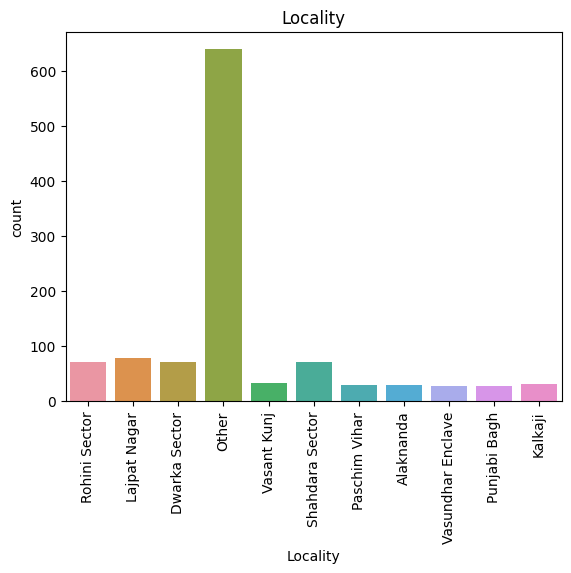

In [67]:
sns.countplot(x = 'Locality', data = df).set_title('Locality')
plt.xticks(rotation = 90)

Since there are so many localities and address in the dataset, I have group nearly half of them in the top ten localities (count wise), and the remaining localities are grouped as 'Others'. Upon visualizing the locality on the graph, we can se that after the 'Other' category, the Dwarka Sector has highest number of houses followed by Lajpat Naagr and Rohini Sector. From this info, I assume that these localities are good to settle in Delhi. In addition to that localities such as Shahdara and Alaknanda are have significant number of houses as well. So, these localities are also good to settle in Delhi.

### Parking

In [70]:
# Get Value Count'Parking' 
print(df['Parking'].value_counts())

Parking
1     744
2     299
3      47
4      12
5       7
10      1
Name: count, dtype: int64


Text(0.5, 1.0, 'Parking')

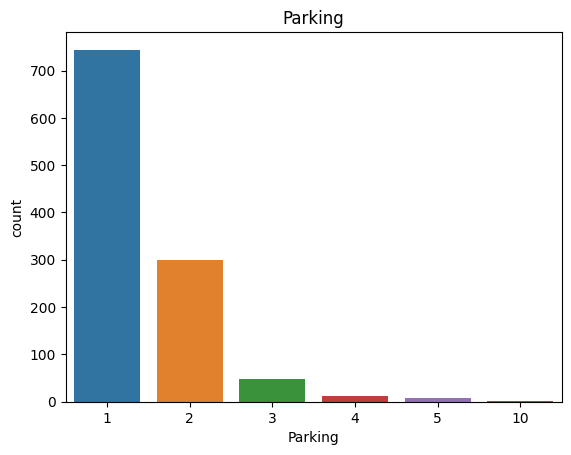

In [71]:
sns.countplot(x = 'Parking', data = df).set_title('Parking')

Majority of the houses in Delhi has one car parking which is quite common. Few of the houses have enough space for two car parking and very few houses have more than two car parking space. We can relate this graph to the graph with house area, where majority of the houses have area between 100 -200 sq. yards. So, it is quite obvious than these house will have one car parking space. The houses with area more than 200 sq. yards will have more than one car parking space.

### Status

In [74]:
# Get Value Count 'Status'
df['Status'].value_counts()

Status
Ready_to_move    1054
Almost_ready       56
Name: count, dtype: int64

Text(0.5, 1.0, 'Status')

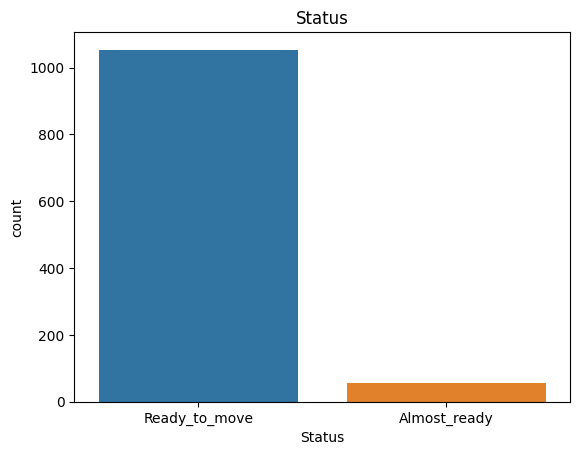

In [75]:
sns.countplot(x = 'Status', data = df).set_title('Status')

Most of the houses are ready to move and actively looking for buyers. Very few houses are still under construction and would be ready to move soon.

### Transaction Type

In [78]:
# Get Value Count 'Transaction Type'
df['Transaction'].value_counts()      

Transaction
Resale          705
New_Property    405
Name: count, dtype: int64

Text(0.5, 1.0, 'Transaction Type')

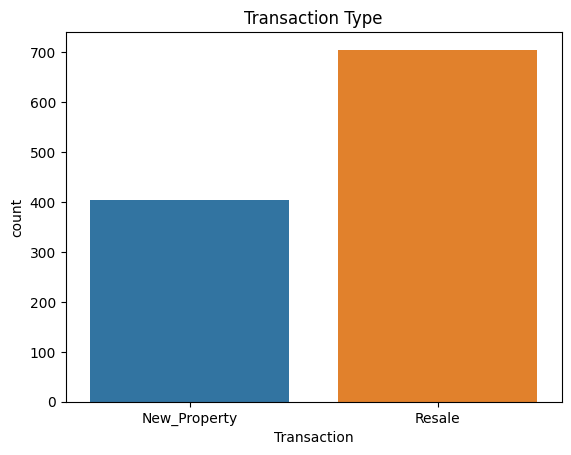

In [79]:
sns.countplot(x = 'Transaction', data = df).set_title('Transaction Type')

A huge number of houses are resale type, which means a lot of people are moving out of Delhi. This could be due to the high pollution levels or some other reason. This could be a good opportunity for people who are looking to buy a house in Delhi. Nearly 430 houses are new property houses which are built with only purpose to be commericially sold.

### House Type

In [82]:
# Get Value Count 'House Type'
df['Type'].value_counts()

Type
Builder_Floor    610
Apartment        500
Name: count, dtype: int64

Text(0.5, 1.0, 'House Types')

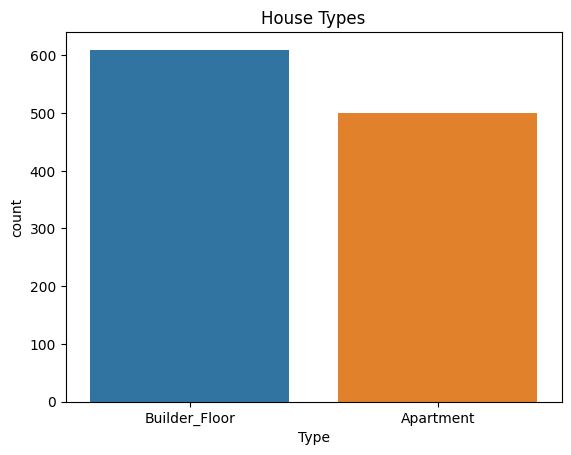

In [83]:
sns.countplot(x = 'Type', data = df).set_title('House Types')

Most of the houses are builder floor which means people like to live in independent houses rather than apartments, due to the privacy and space they get in independent houses.

Till now, I have visualize the distribution of data across variables in the dataset. Now, I will be looking at the realtion between the target variable i.e Price and independent variables.

### Area and Price

<Axes: xlabel='Area_Yards', ylabel='Price'>

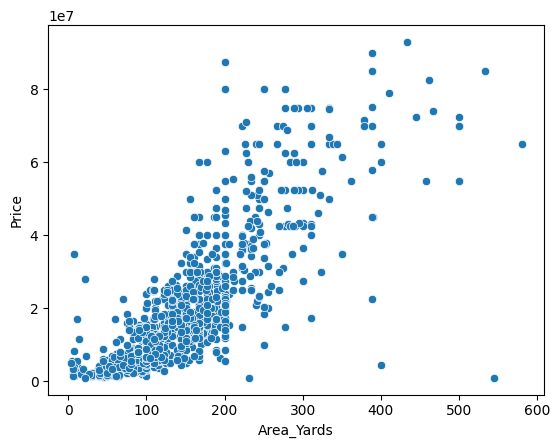

In [87]:
sns.scatterplot(x = 'Area_Yards', y = 'Price', data = df)

The scatter plot reveals a positive correlation between house area and price. Nonetheless, certain properties deviate from this trend, suggesting that additional factors such as locality, number of bedrooms (BHK), furnishing, and property type play a significant role in determining house prices.

### BHK and Price

<Axes: xlabel='BHK', ylabel='Price'>

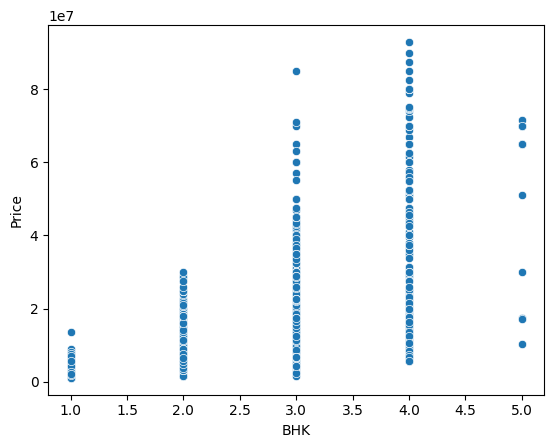

In [90]:
# Plot a 'Scatter Plot' to view the relation between 'BHK' and 'Price'
sns.scatterplot(x = 'BHK', y = 'Price', data = df)

A scatter plot gives a point-wise idea but can be noisy if you have many data points.

Text(0.5, 1.0, 'BHK vs Price')

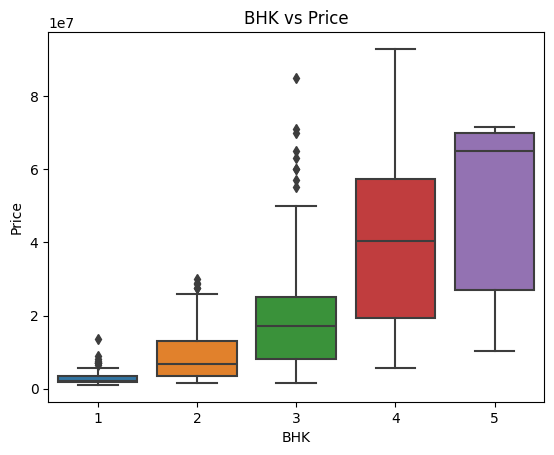

In [92]:
# Create a 'Box Plot' for 'BHK' and 'Prices'
# A boxplot is best for showing median trends and spread in prices for each BHK category.
sns.boxplot(x = 'BHK', y = 'Price', data = df).set_title('BHK vs Price')

From this box plot, we get to know about the relation between the price of the house and the BHK count. We can see that the price of the house increases with the increase in the BHK count, which evident from the fact that 5 BHK houses have the highest median price i.e. nearly 7,00,00,000 INR followed by 4 BHK houses with median price of nearly 4,00,00,000 INR. Incomparison to that, 3BHK houses have median price near about 1 crore INR and 2BHK houses have median price of nearly 50,00,000 INR. The 1BHK houses have the lowest median price of nearly 30,00,000 INR.

The boxplot shows that the median price of houses generally increases with the number of bedrooms (BHK). However, there is a wide variation in prices within each BHK category, indicating that other features such as locality, area, and furnishing status also influence the price. In some cases, a 2 BHK house may be priced higher than a 3 BHK house due to its prime location or better amenities.

### Bathroom Cound and Price

Text(0.5, 1.0, 'Bathroom Count vs Price')

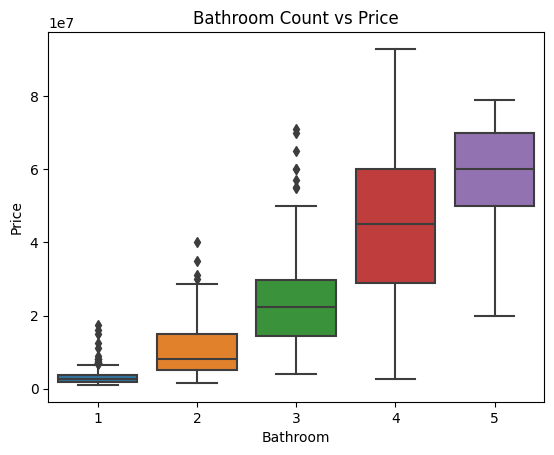

In [96]:
sns.boxplot(x = 'Bathroom', y = 'Price', data = df).set_title('Bathroom Count vs Price')

The graph is similar to the previous graph for BHK and Price. Here the price of the house increases with increase in the number of bathrooms. Moreover the each bathroom count has similar house price as the previous graph for BHK and Price. Therefore, we can say that number of bathrooms and the BHK of the house are highly correlated.

### Parking and Price

Text(0.5, 1.0, 'Parking vs Price')

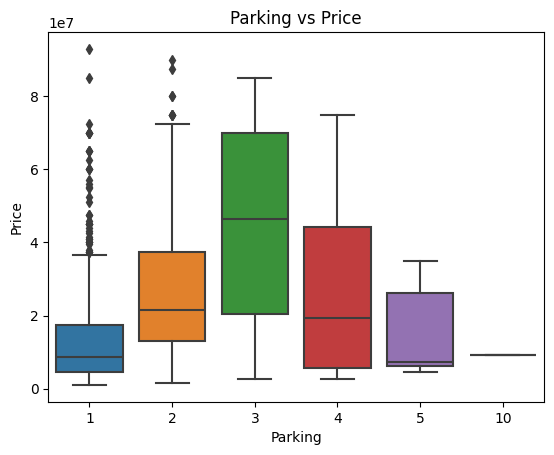

In [99]:
sns.boxplot(x = 'Parking', y = 'Price', data = df).set_title('Parking vs Price')

This boxplot graphs shows the relationship between the parking space and the price of the house. Houses with 3 parking spaces has highest median price which is 4,50,00,000, followed by 3 parking space, 2 parking space and 1 parking space. From this graph, we can assume that people usually look for the houses to have sufficient parking space, which means they don't want more than enough space for parking which evident throught the lower median price of houses with 4 parking space or more.

### Locality and Price

Text(0.5, 1.0, 'Locality vs Price')

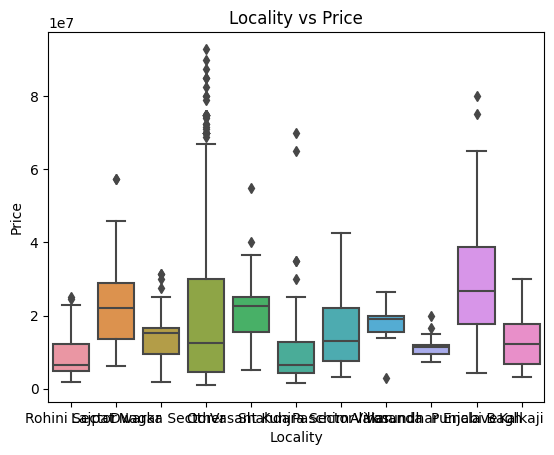

In [102]:
sns.boxplot(x = 'Locality', y = 'Price', data = df).set_title('Locality vs Price')

From this graph, we can get idea about the localities along with the house price. Punjabi Bagh locality has the highest median price of nearly 2,50,00,000 INR, which means this is a posh locality. Punjabi Bagh is followed by Lagpat Nagar and Vasant Kunj. These two localities can be included in the posh locality. The localities with lowest median prices includes - Rohini Sector, Vasundhara Enclave and Shahdara. Some of the mediocre localities are - Dwarka Sector, Pashchim Vihar, Kalkaji, and the rest of the localities are average.

### Furnishing and Price

Text(0.5, 1.0, 'Furnishing vs Price')

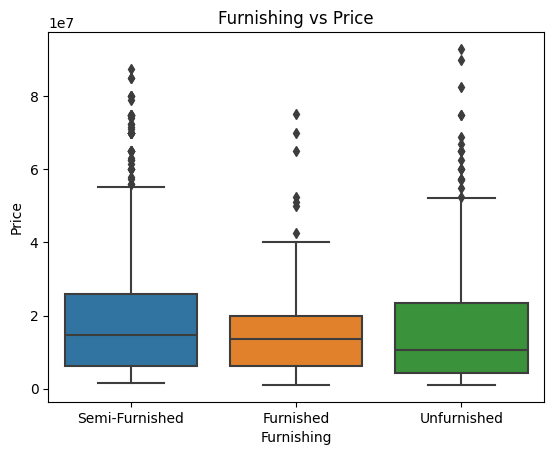

In [105]:
sns.boxplot(x = 'Furnishing', y = 'Price', data = df).set_title('Furnishing vs Price')

There is very little difference in the median house price based on the furnishing status. Interestingly, the furnished houses have a lower median price than the semi-furnished houses. The unfurnished houses have the lowest median price.

### Status and Price

Text(0.5, 1.0, 'Status vs Price')

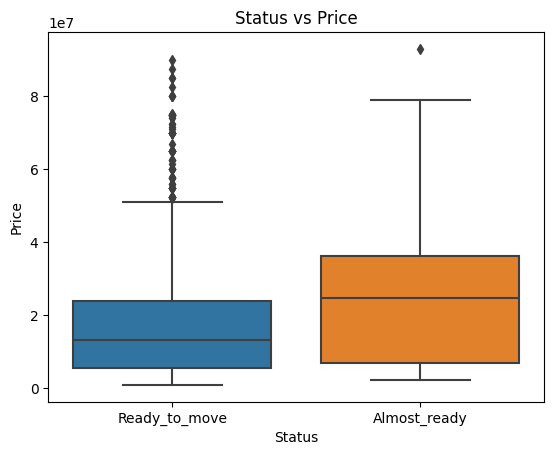

In [108]:
sns.boxplot(x = 'Status', y = 'Price', data = df).set_title('Status vs Price')

Surprisingly the houses that are still under construction have higher median price than those which are ready to move in. This might be because the houses that are still under construction allow the buyers to make changes to interior/exterior.

### Tansaction Type and Price

Text(0.5, 1.0, 'Transaction vs Price')

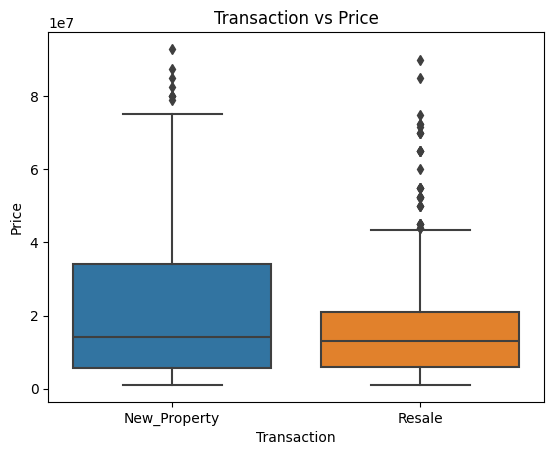

In [111]:
sns.boxplot(x = 'Transaction', y = 'Price', data = df).set_title('Transaction vs Price')

As expected the new properties have higher price than old ones/ resale ones. The new properties attracts more buyers to make features including reliability, designs. Whereas the resale one sometimes poses doubts for the buyers.

### Property Type and Price

Text(0.5, 1.0, 'Type vs Price')

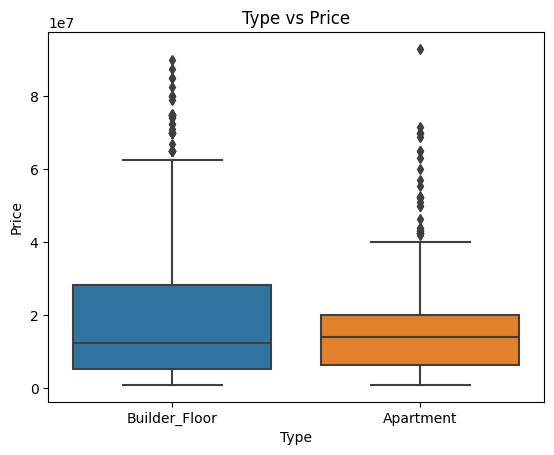

In [114]:
sns.boxplot(x = 'Type', y = 'Price', data = df).set_title('Type vs Price')

Both the Builder Floor and Apartment type houses have nealry same median price with Apartment type houses having slightly higher median price. However, the builder floor type houses are more in number which means people are more interested in buying builder floor type houses.

### Label Encoding the categorical variables

In the dataset, several features such as Furnishing, Locality, Status, Transaction, and Type are categorical in nature and cannot be directly used for model training. Therefore, label encoding is applied to convert these categorical variables into numerical values. This transformation ensures that the dataset can be processed efficiently by machine learning algorithms.

In [117]:
# Import label Encoder library
from sklearn.preprocessing import LabelEncoder

# Create label Encoder Object
le = LabelEncoder()
le

LabelEncoder()

In [118]:
# Columns for Label Encoding
columns = ['Furnishing', 'Locality', 'Status', 'Transaction', 'Type']

# Apply Label Encoding to each column
for col in columns:
    df[col] = le.fit_transform(df[col])

# Display the first few rows after encoding
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,Area_Yards
0,800.0,3,2,1,7,1,6500000,1,0,1,8125.0,88.888889
1,750.0,2,2,1,7,1,5000000,1,0,0,6667.0,83.333333
2,950.0,2,2,0,7,1,15500000,1,1,0,6667.0,105.555556
3,600.0,2,2,1,7,1,4200000,1,1,1,6667.0,66.666667
4,650.0,2,2,1,7,1,6200000,1,0,1,6667.0,72.222222


### Normalizing the continuous features

After label encoding the categorical features, the next step is normalizing continuous (numerical) features so that all numeric values are on a similar scale. This helps machine learning models (like linear regression, k-NN, or neural networks) perform better and converge faster.

Note: You may exclude 'Price' it’s target variable, depending on the model. Usually, only features (X) are normalized, not the target (y).

In [120]:
# Import MinMax Scaler Library
from sklearn.preprocessing import MinMaxScaler

# Initialize the Scaler
min_max = MinMaxScaler()
min_max

MinMaxScaler()

In [121]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'Per_Sqft', 'Area_Yards'],
      dtype='object')

In [122]:
# Continuous Features to Normalize
df [['Area', 'Price', 'Per_Sqft', 'Area_Yards']] = MinMaxScaler().fit_transform(df[['Area', 'Price', 'Per_Sqft', 'Area_Yards']])

In [123]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,Area_Yards
0,0.148690,3,2,1,7,1,0.059783,1,0,1,0.097173,0.148690
1,0.139060,2,2,1,7,1,0.043478,1,0,0,0.076565,0.139060
2,0.177581,2,2,0,7,1,0.157609,1,1,0,0.076565,0.177581
3,0.110169,2,2,1,7,1,0.034783,1,1,1,0.076565,0.110169
4,0.119800,2,2,1,7,1,0.056522,1,0,1,0.076565,0.119800


The continuous features were normalized using Min-Max scaling to bring all numeric values into the range [0,1]. This ensures that features with larger ranges, such as Area and Per_Sqft, do not disproportionately influence the model training process. Normalization improves model performance and convergence.

### Coorelation Matrix Heatmap

After preprocessing, it’s a good idea to analyze how numerical features relate to each other and the target (Price). A correlation matrix heatmap is ideal for this.
* Shows the strength and direction of relationships between numerical features.
* Values range from -1 to 1:
  * 1 → perfect positive correlation
  * -1 → perfect negative correlation
  * 0 → no correlation

<Axes: >

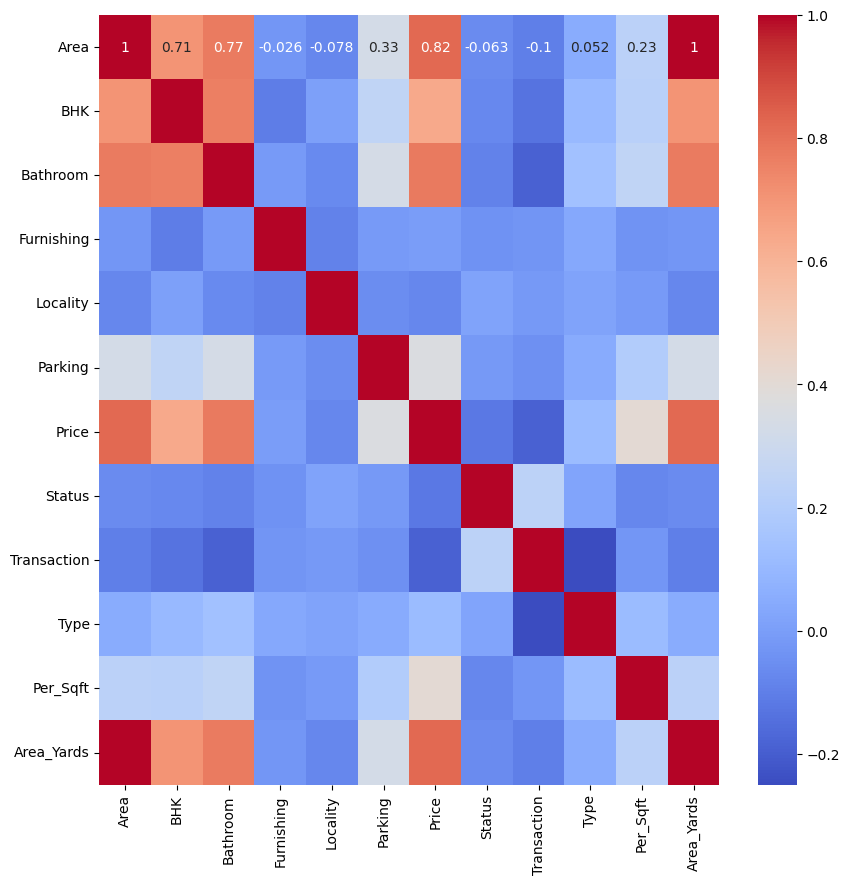

In [127]:
plt.figure(figsize = (10, 10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

In this coorelation matrix heatmap, we can see that the price of the house has high positive coorelation with land area, BHK, bathroom count, which proves are previous obersevation about their relation.

* Look at the correlation of Price with other features:
  * High positive correlation → feature increases, Price increases
  * High negative correlation → feature increases, Price decreases
* For example:
  * Area and Per_Sqft might show strong positive correlation with Price
  * BHK may also have a moderate positive correlation
  * Features with very low correlation may not be very important for price prediction

A correlation matrix heatmap was plotted to examine the relationships between numerical features and the target variable Price. The heatmap shows that features such as Area, Per_Sqft, and BHK have a positive correlation with Price, indicating that larger and well-sized houses tend to be more expensive. Features with low correlation may have a smaller influence on price prediction.

### Train Test Split

In [130]:
# Dropping 'Per_Sqft' column
df.drop(['Per_Sqft'], axis = 1, inplace = True)

In [131]:
# Assigning the Independent and Target Variable
X = df.drop('Price', axis = 1)
y = df['Price']

In [132]:
# Applying 'Train Test Split' Function
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [133]:
# Check the Train, Test shape
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (777, 10)
y_train: (777,)
X_test: (333, 10)
y_test: (333,)


### Price Prediction 

I will be using the following models:

* Decision Tree Regressor
* Random Forest Regressor

# Decision Tree Regressor

In [136]:
# Import Decision Tree Regressor Library
from sklearn.tree import DecisionTreeRegressor

# Creating Decision Tree Regressor Object
dtr = DecisionTreeRegressor()
dtr

DecisionTreeRegressor()

In [137]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor()

In [138]:
# Predicting the Diagnosis
y_pred = dtr.predict(X_test)
y_pred

array([0.01630435, 0.07608696, 0.08597826, 0.19565217, 0.69565217,
       0.80434783, 0.05978261, 0.09565217, 0.12971014, 0.11413043,
       0.08152174, 0.64130435, 0.13043478, 0.09782609, 0.25978261,
       0.16847826, 0.38586957, 0.29891304, 0.07065217, 0.025     ,
       0.80434783, 0.04891304, 0.38586957, 0.91304348, 0.06304348,
       0.16304348, 0.5326087 , 0.31521739, 0.05978261, 0.16032609,
       0.11141304, 0.16847826, 0.39673913, 0.16086957, 0.17934783,
       0.22826087, 0.08152174, 0.05434783, 0.33152174, 0.13043478,
       0.39673913, 0.80434783, 0.125     , 0.17391304, 0.11304348,
       0.02717391, 0.125     , 0.28804348, 0.1576087 , 0.33152174,
       0.14347826, 0.07608696, 0.14347826, 0.27717391, 0.26086957,
       0.02173913, 0.11195652, 0.00543478, 0.17934783, 0.07771739,
       0.025     , 0.05978261, 0.15652174, 0.00923913, 0.01358696,
       0.15217391, 0.16086957, 0.22826087, 0.04891304, 0.80434783,
       0.14945652, 0.80434783, 0.11956522, 0.07771739, 0.38260

### Model Evaluation for Decision Tree Regressor

In [140]:
# Printing Samples from Predicted and Actual Values
print("Predicted Values:", y_pred[:10])
print("Actual Values:", y_test[:10])

Predicted Values: [0.01630435 0.07608696 0.08597826 0.19565217 0.69565217 0.80434783
 0.05978261 0.09565217 0.12971014 0.11413043]
Actual Values: 341     0.038043
601     0.228261
137     0.157609
718     0.195652
271     0.505435
546     0.804348
827     0.032609
962     0.114130
1242    0.059783
144     0.168478
Name: Price, dtype: float64


In [141]:
# Model Evaluation
print(dtr.score(X_test, y_test))

0.5748276074430648


### Decision Tree Regressor - Hyperparametertuning the model with GridSearchCV

In [143]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [144]:
# Defining parameters
parameters = {'max_depth': [2, 4, 6, 8],
              'min_samples_split': [2, 4, 6, 8],
              'min_samples_leaf': [1, 2, 3, 4],
              'max_features': ['auto', 'sqrt', 'log2'],
              'random_state': [0, 42]
             }

# Creating GridSearchCV Object
grid_search = GridSearchCV(dtr, parameters, cv = 5, scoring =  'neg_mean_squared_error')

# Fitting data to grid search object
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'random_state': 0}


In [145]:
dtr = DecisionTreeRegressor(max_depth = 8, max_features = 'sqrt', min_samples_leaf = 4, min_samples_split = 2, random_state = 0)
dtr

DecisionTreeRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=4,
                      random_state=0)

In [146]:
# Training the model
dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=4,
                      random_state=0)

In [147]:
# Training Accuracy
dtr.score(X_train, y_train)

0.8276772165213161

In [148]:
# Predicting the 'House Price'
d_pred = dtr.predict(X_test)
d_pred

array([0.01473913, 0.26615942, 0.05292788, 0.17481884, 0.5666388 ,
       0.73641304, 0.05292788, 0.18519022, 0.09803795, 0.05292788,
       0.12971014, 0.73505435, 0.07882812, 0.05292788, 0.15887681,
       0.2315967 , 0.17826087, 0.16350932, 0.08410326, 0.01979814,
       0.26304348, 0.09803795, 0.42857143, 0.63858696, 0.13007246,
       0.14762174, 0.18328804, 0.2826087 , 0.05292788, 0.14762174,
       0.14762174, 0.16038647, 0.5375    , 0.09803795, 0.14762174,
       0.19809783, 0.17826087, 0.07882812, 0.2315967 , 0.30264946,
       0.42857143, 0.61141304, 0.21603261, 0.01473913, 0.2315967 ,
       0.02110507, 0.09803795, 0.15809179, 0.21603261, 0.2315967 ,
       0.26766304, 0.09803795, 0.15809179, 0.19809783, 0.16350932,
       0.02110507, 0.16350932, 0.00966184, 0.16038647, 0.09803795,
       0.08410326, 0.06652174, 0.16719368, 0.01328502, 0.01979814,
       0.09803795, 0.09803795, 0.16038647, 0.13043478, 0.73641304,
       0.05292788, 0.63858696, 0.14211957, 0.09803795, 0.40688

### Evaluating Decision Tree Regressor Model

In [150]:
dft = pd.DataFrame({'Actual': y_test, 'Predicted': d_pred})
dft.reset_index(drop = True, inplace = True)
dft.head()

,Actual,Predicted
0,0.038043,0.014739
1,0.228261,0.266159
2,0.157609,0.052928
3,0.195652,0.174819
4,0.505435,0.566639


<Axes: xlabel='Predicted', ylabel='Density'>

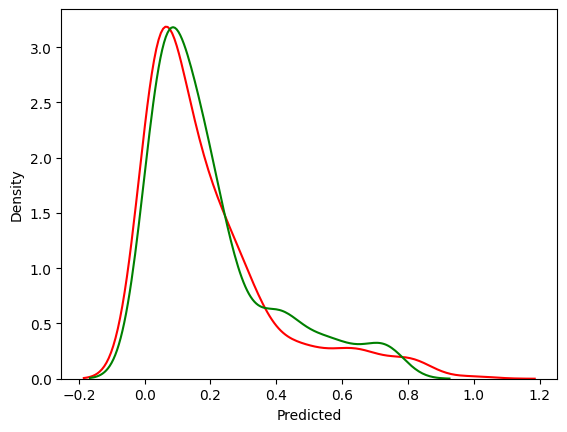

In [151]:
ax = sns.distplot(dft['Actual'], color = 'r', label = 'Actual Price', hist = False)
sns.distplot(dft['Predicted'], color = 'g', label = 'Predicted Price', ax = ax, hist = False)

The red shows the distribution count for actual values and the green shows the distribution count for predicted values. The predicted value line tries to follow the actual value line as closely as possible. The closer the two lines are, the better the model is at predicting the house prices.

In [153]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print("R2 Score: ", r2_score(y_test, d_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, d_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, d_pred))
print("Root Mean Squared Error: ", np.sqrt(mean_squared_error(y_test, d_pred)))

R2 Score:  0.7137374502428073
Mean Squared Error:  0.011043899689835346
Mean Absolute Error:  0.06904660341553379
Root Mean Squared Error:  0.10508995998588708


## Random Forest Regressor

In [155]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [156]:
# Create Random Forest Regressor Object
rfr = RandomForestRegressor()
rfr

RandomForestRegressor()

In [157]:
# Training the model
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [158]:
# Training Accuracy
rfr.score(X_train, y_train)

0.9583932399908393

In [159]:
# Predicting the house price
r_pred = rfr.predict(X_test)
r_pred

array([0.02126739, 0.26370236, 0.1266163 , 0.19138043, 0.59123913,
       0.74766304, 0.07572415, 0.12790761, 0.12660743, 0.07728333,
       0.09618478, 0.7175    , 0.12076196, 0.0598913 , 0.24789565,
       0.16865217, 0.27998279, 0.26265942, 0.05604348, 0.03648913,
       0.52478261, 0.05995652, 0.43015761, 0.78086957, 0.09560598,
       0.15339855, 0.42407971, 0.37746739, 0.06644565, 0.17227083,
       0.15743297, 0.21116848, 0.31598913, 0.1462154 , 0.15903043,
       0.16946739, 0.25060109, 0.05603152, 0.3154212 , 0.18345652,
       0.34316304, 0.60433333, 0.18123913, 0.08639239, 0.18076087,
       0.0225029 , 0.10299493, 0.18986957, 0.16206522, 0.3154212 ,
       0.14386957, 0.08636504, 0.15281703, 0.18245109, 0.29131522,
       0.02500543, 0.16852899, 0.00791304, 0.17694565, 0.13497428,
       0.07401087, 0.05716304, 0.16026377, 0.01103804, 0.02080163,
       0.08434873, 0.10250072, 0.13582143, 0.11341304, 0.77532609,
       0.14105983, 0.67655435, 0.15608696, 0.13497428, 0.39190

### Evaluating the Random Forest Regressor Model

In [161]:
dfr = pd.DataFrame({'Actual': y_test, 'Predicted': r_pred})
dfr.reset_index(drop=True, inplace=True)
dfr.head()

,Actual,Predicted
0,0.038043,0.021267
1,0.228261,0.263702
2,0.157609,0.126616
3,0.195652,0.191380
4,0.505435,0.591239


<Axes: xlabel='Predicted', ylabel='Density'>

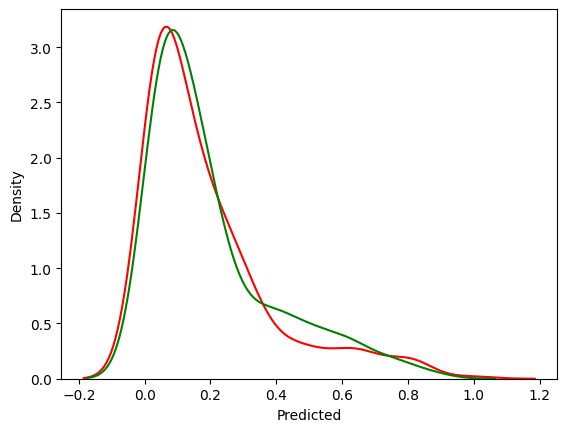

In [162]:
ax = sns.distplot(dfr['Actual'], color = 'r', label = 'Actual Price', hist = False)
sns.distplot(dfr['Predicted'], color = 'g', label = 'Predicted Price', ax=ax, hist = False)

The red shows the distribution count for actual values and the green shows the distribution count for predicted values. The predicted value line tries to follow the actual value line as closely as possible. The closer the two lines are, the better the model is at predicting the house prices.

In [164]:
print("R2 Score: ", r2_score(y_test, r_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, r_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, r_pred))
print("Root Mean Squared Error: ", np.sqrt(mean_squared_error(y_test, r_pred)))

R2 Score:  0.7552396028929012
Mean Squared Error:  0.009442762512902356
Mean Absolute Error:  0.06078251834909442
Root Mean Squared Error:  0.09717387772906028


### Linear Regression

In [166]:
# Import Linear Regression Library
from sklearn.linear_model import LinearRegression

In [167]:
# Create Linear Regression Model
lr = LinearRegression()
lr

LinearRegression()

In [168]:
# Fit the model into Training data
lr.fit(X_train, y_train)

LinearRegression()

In [169]:
# Make predictions on Test Data
y_pred = lr.predict(X_test)
y_pred

array([-0.03062671,  0.2775425 ,  0.1083276 ,  0.2063807 ,  0.44309187,
        0.64680711,  0.08992513,  0.16338279,  0.1245073 ,  0.09879313,
        0.10686029,  0.78646854,  0.09403494,  0.05734904,  0.16830408,
        0.22829067,  0.28331708,  0.21389738,  0.05844582,  0.01029462,
        0.49689335,  0.10364841,  0.42040338,  0.66723242,  0.16794222,
        0.10492946,  0.26077654,  0.29519018,  0.06627577,  0.15892991,
        0.152024  ,  0.22062591,  0.28162269,  0.1226293 ,  0.15622037,
        0.20915345,  0.35795424,  0.0951814 ,  0.23773355,  0.26543923,
        0.39124085,  0.62101907,  0.17407523, -0.02908732,  0.22632619,
        0.01633245,  0.09528171,  0.15176474,  0.1753413 ,  0.23773355,
        0.1612347 ,  0.1493557 ,  0.19306545,  0.21709883,  0.24019285,
       -0.02983092,  0.20736221, -0.04909097,  0.22987023,  0.14365952,
        0.0841354 ,  0.10020335,  0.2389044 , -0.02030078,  0.01219491,
        0.07311443,  0.12337144,  0.31118592,  0.13924308,  0.66

In [170]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print Results
print("Linear Regression Model Evaluation")
print("------------------------------------")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Linear Regression Model Evaluation
------------------------------------
R² Score: 0.7061
Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.11


In [171]:
# Compare Actual vs Predicted Values
dft = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nSample Comparison:")
print(dft.head(10))


Sample Comparison:
        Actual  Predicted
341   0.038043  -0.030627
601   0.228261   0.277542
137   0.157609   0.108328
718   0.195652   0.206381
271   0.505435   0.443092
546   0.804348   0.646807
827   0.032609   0.089925
962   0.114130   0.163383
1242  0.059783   0.124507
144   0.168478   0.098793


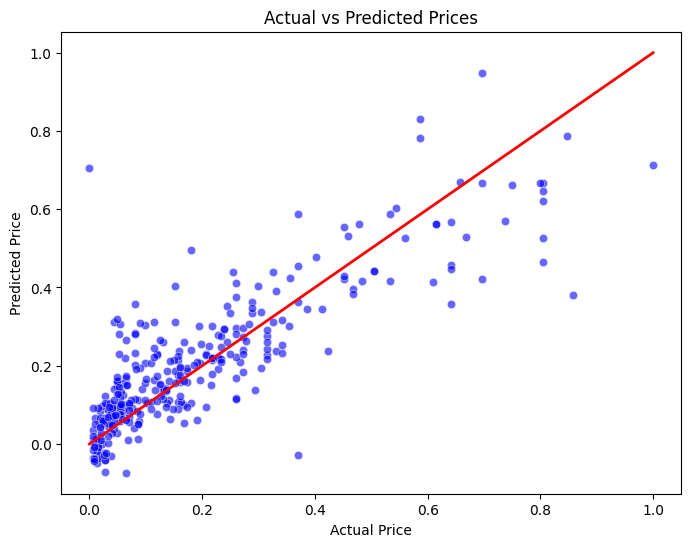

In [172]:
# Visualization of Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x='Actual', y='Predicted', data=dft, color='blue', alpha=0.6)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot([dft['Actual'].min(), dft['Actual'].max()],
         [dft['Actual'].min(), dft['Actual'].max()],
         color='red', lw=2)  # Diagonal reference line
plt.show()

## Conclusion

From the exploratory data analysis, we can conclude that the following features are important for predicting the price of a house in Delhi:

1. Area
2. BHK
3. Locality

From the EDA it was also found that, most of the houses in delhi are small having area between 100 to 200 sq. yards having 2-3 BHK. The price of the houses in localities such as Punjabi Bagh, Lajpat nagar and Vasant Kunj are high as compared to other localities, which means these are posh areas of Delhi. Most of the people prefer a new builder floor property despite the aprtments cost the same because people want to design their house according to their own needs and requirements and want more privacy and independency.

Coming to the machine learning models, I have used regression models - Decision Tree Regressor and Random Forest Regressor. The Random Forest regressor performed better than the Decision Tree Regressor with an accuracy of 76.36%